투명 사출물 결함 검수 및 로봇 자동화 공정 시스템 (TEAM 더듬이)
기존 비전 센서의 한계(빛 반사, 굴절)를 극복하기 위해 물리적 스캔(Haptic Scanning) 방식을 도입한 투명 재질 전용 자동 검수 솔루션입니다. 로봇의 토크 센서 데이터를 실시간으로 분석하여 미세한 결함을 찾아내고, 시료의 이송 및 관리 공정을 자동화합니다.

1) 시스템 설계 및 핵심 노드
본 프로젝트는 두산 로보틱스에서 제공하는 패키지를 이용한 프로젝트입니다.
통합 런치 파일 없이, 각 모듈의 독립성을 보장하기 위해 4개의 핵심 파이썬 스크립트를 개별 구동하는 마이크로 서비스 아키텍처로 구성되어 있습니다.

-운영체제 환경

권장/테스트 기준(예시):

- **OS**: Ubuntu 22.04 LTS
- **ROS 2**: Humble Hawksbill
- **Python**: 3.10.x (ROS 2 Humble 기본)
- **로봇 드라이버/패키지**
  - `dsr_bringup2` (런치에서 include)
  - `DSR_ROBOT2` (Python API, 두산 로봇 제어)
 
<img width="1102" height="553" alt="image" src="https://github.com/user-attachments/assets/cb95fad8-5e4c-4020-8c96-069e07b4d8ec" />
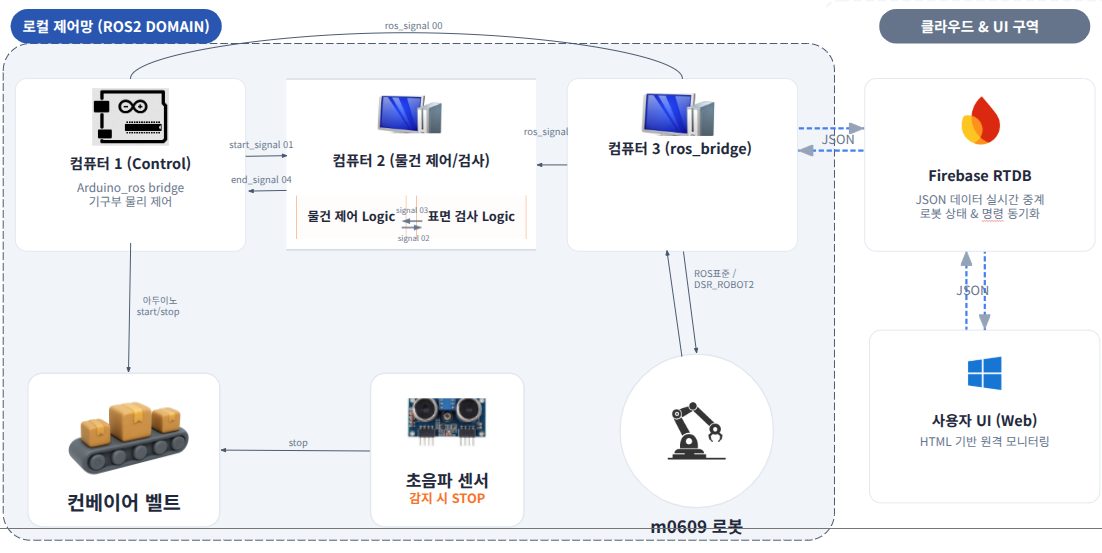

설명: UI, 각 노드(스크립트), 두산 로봇, 그리고 Firebase 간의 데이터 흐름(Pub/Sub, API 연동)이 잘 나타난 아키텍처 이미지가 들어갈 자리입니다.

2) 디렉토리 및 파일 구조
cobot_ws/
├── build/
├── install/
├── log/
└── src/
    └── cobot1/                     # 메인 ROS 2 패키지
        ├── cobot1/                 # 핵심 노드 스크립트
        │   ├── __init__.py
        │   # [핵심 로직 스크립트]
        │   ├── total_control.py             # 통합 관제 UI 및 메인 로직
        │   ├── task_controller_FINAL.py     # 공정 작업 시퀀스 제어 메인 엔진 (추가)
        │   ├── torque_monitor_09.py         # 햅틱 스캐닝 및 결함 분석
        │   ├── firebase_04.py               # 리포트 생성 및 클라우드 업로드
        │   ├── 05_01_ros_firebase_bridge.py # ROS-Firebase 상태 동기화
        │   ├── conveyor_sensor_bridge_FINAL.py # 컨베이어 센서 데이터 브릿지 (추가)
        │   # [웹 리포트 및 모니터링 템플릿]
        │   ├── 10_index.html                # 모니터링 대시보드 메인 페이지 (추가)
        │   └── 3d_view_09.html              # 3D 궤적 시각화 리포트 템플릿 (추가)
        ├── arduino/
        │   └── FINAL.ino                    # 컨베이어 제어용 아두이노 소스 코드 (추가)
        ├── package.xml
        └── setup.py
        
3) 설치 및 실행 방법
-의존성 설치
본 프로젝트는 Python 3.10 및 ROS 2 Humble 환경에서 동작합니다. 터미널을 열고 아래 필수 라이브러리를 설치해 주세요.

pip install firebase-admin numpy scipy plotly PySide6


-시스템 구동 방법
이 시스템은 4개의 개별 터미널을 열어 각각의 스크립트를 실행해야 합니다. 모든 터미널에서 ROS 2 환경(setup.bash)이 소스(source)되어 있어야 합니다.

```bash
# ROS 2 환경
source /opt/ros/humble/setup.bash

# 워크스페이스 예시
mkdir -p ~/cobot_ws/src
cd ~/cobot_ws/src

# 이 저장소의 src/ 내용을 복사/클론했다고 가정
cd ~/cobot_ws
colcon build --symlink-install
source install/setup.bash
```

총 3대의 pc를 이용할 예정


```bash
# <PC1>
# Terminal 1: 두산 로봇팔 모델과 연결
ros2 launch dsr_bringup2 dsr_bringup2_rviz.launch.py mode:=real host:=192.168.1.100 port:=12345 model:=m0609

# Terminal 2: 통합 제어 및 UI 실행
python3 total_control.py

# Terminal 3: 결함 분석 (햅틱 스캐닝) 노드 실행
python3 torque_monitor_09.py

# Terminal 4: Firebase 리포트 매니저 실행
python3 firebase_04.py
```

```bash
# <PC2>
# Terminal 1: ROS-Firebase 통신 브릿지 실행
python3 05_01_ros_firebase_bridge.py
```

```bash
# <PC3>
# Terminal 1: ROS-Arduino 통신 브릿지 실행
python3 conveyor_sensor_bridge_FINAL.py

# Terminal 2: ROS-Arduino 통신 관리 실행
python3 task_controller_FINAL.py
```


4) 핵심 로직: 토크 피드백 기반 결함 검출

설명: 0.05초 주기의 데이터 수집 -> 진입 안정화(1초) -> 토크 스파이크 감지(1.7Nm 이상)

안정화 구간 설정: 진입 초기 기계적 진동으로 인한 노이즈를 무시하기 위해 초기 20프레임(약 1초)은 데이터 분석에서 제외합니다.

실시간 스파이크 감지: 정상 범위를 벗어나는 1.7Nm 이상의 외부 토크 변화가 발생할 경우 이를 '결함 의심 구간(크랙)'으로 판별합니다.

Cubic Spline 경로 분석: 의심 구간 전후의 정상 궤적을 3차 스플라인으로 보간하여 '이상적 궤적'을 추정하고, 실제 로봇이 밀려난 경로와의 최대 편차를 계산합니다.

최종 판정: 오차율이 5%를 초과할 경우 FAIL 판정을 내리고 불량 리포트 생성을 트리거합니다.



5) 데이터 관리 및 디지털 트윈
Realtime Database: 브릿지 스크립트(05_01_ros_firebase_bridge.py)를 통해 로봇의 조인트 상태, 검수 진행률, TCP 좌표를 실시간으로 웹/모바일과 동기화합니다.

Cloud Storage: firebase_04.py가 불량 발생 시 Plotly 기반의 인터랙티브 3D 궤적 리포트(HTML)를 렌더링하여 클라우드에 영구 보관합니다.



6) 향후 개선 및 기대 효과
안전성 강화: 긴급 정지(Emergency Stop) 및 장애물 회피(H2R 모드) 로직의 정교화.

확장성: 투명 사출물 외에도 비전 센서 활용이 어려운 고반사 재질(금속 등)의 표면 검수로 확장 가능.

시스템 통합: 개별 실행되는 4개의 스크립트를 하나로 묶어주는 ROS 2 Launch 파일 작성 예정.
